# Production-Ready OCR &
# Document Understanding
# Mastery Challenge

## Step 3: Synthetic / Dummy Dataset Generation
## Research/Learn:


- Faker: Python library is used to generate field data such as name, address, phone number, invoice number...
- ReportLab: Python library for generating PDFs and graphics.


In [1]:
# %pip install faker reportlab pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [faker]32m1/2 [faker]
Note: you may need to restart the kernel to use updated packages.


### Generate field data using Faker

In [6]:
from faker import Faker
import json
fake = Faker()

results = []

for _ in range(3):
    entry = {
        "name": fake.name(),
        "job": fake.job(),
        "address": fake.address().replace('\n', ', '),
        "credit_card": fake.credit_card_number(card_type='visa')
    }
    results.append(entry)

print(json.dumps(results, indent=4))

[
    {
        "name": "Julie Campbell",
        "job": "Manufacturing engineer",
        "address": "15411 Fitzpatrick Flat Apt. 471, Lake Toddstad, AL 95588",
        "credit_card": "4066543225855834"
    },
    {
        "name": "Mr. Anthony Castro",
        "job": "Musician",
        "address": "540 Heather Stravenue Apt. 636, Grayborough, IN 61780",
        "credit_card": "4942298018089345"
    },
    {
        "name": "Chris Harris",
        "job": "Market researcher",
        "address": "3675 Brown Ways, Melissashire, NM 79440",
        "credit_card": "4257075520542089"
    }
]


### Generate PDF using ReportLab

In [26]:
import os
from faker import Faker
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont

fake = Faker()

try:
    pdfmetrics.registerFont(TTFont('Arial', 'Arial.ttf'))
    font_name = "Arial"
except:
    font_name = "Helvetica"


def create_pdf():
    folder = "ocr-project"
    os.makedirs(folder, exist_ok=True)

    filename = "document.pdf"
    filepath = os.path.join(folder, filename)

    c = canvas.Canvas(filepath, pagesize=A4)
    width, height = A4

    name = fake.name()
    address = fake.address().replace('\n', ', ')
    date = fake.date()

    current_y = height - 50

    c.setFont(font_name, 14)
    c.drawString(50, current_y, "Informations")

    c.setFont(font_name, 12)

    current_y -= 30
    c.drawString(50, current_y, f"Name: {name}")

    current_y -= 20
    c.drawString(50, current_y, f"Address: {address}")

    current_y -= 20
    c.drawString(50, current_y, f"Date: {date}")

    c.showPage()
    c.save()

    if os.path.exists(filepath):
        print(f" {os.path.abspath(filepath)}")
    else:
        print("Error creating file")


create_pdf()

 /home/jupyter/ocr-project/document.pdf


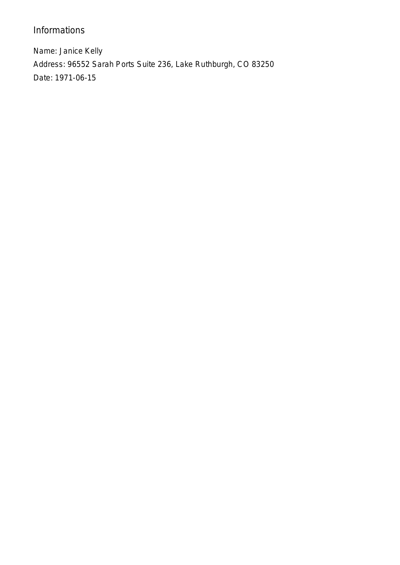

In [66]:
# from IPython.display import IFrame
# IFrame("document.pdf", width=800, height=500)

from pdf2image import convert_from_path
from IPython.display import display

path = "document.pdf"

images = convert_from_path(path)

for img in images:
    w, h = img.size
    new_w = 400
    new_h = int(h * new_w / w) 
    display(img.resize((new_w, new_h)))

## Actions and 

Generate balanced dummy dataset for all document types (images + PDFs) with ground-truth labels.

--> 1000 sample for each document type.
Workflow: Raw data (Faker) --> PDF (ReportLab) --> Label --> Create noise


In [21]:
%pip install pdf2image albumentations opencv-python-headless Pillow

  Using cached pdf2image-1.17.0-py3-none-any.whl.metadata (6.2 kB)
Using cached pdf2image-1.17.0-py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 60.5 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 75.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 87.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.5/583.5 kB 28.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 91.0 MB/s  0:00:00
  Attempting uninstall: pydanticm╸━━━━━━━━━━━━━━━━━━  6/11 [opencv-python-headless]
    Found existing installation: pydantic 1.10.26━━━━━━━━━━━━━  6/11 [opencv-python-headless]
    Uninstalling pydantic-1.10.26:╸━━━━━━━━━━━━━━━━━━  6/11 [opencv-python-headless]
      Successfully uninstalled pydantic-1.10.26━━━━━━━━━━━━━━━  6/11 [opencv-python-headless]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [albumentations]m [albumentations]ess]
ERROR: pip's dependency resolve

1. Generate raw data

In [22]:
import random
from faker import Faker
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4

fake = Faker('en_US')


In [28]:
def step1_generate_invoice():
    previous_reading = random.randint(1000, 9000)
    kwh_used         = random.randint(50, 500)
    current_reading  = previous_reading + kwh_used
    price_per_kwh    = round(random.uniform(0.10, 0.20), 4)
    service_amount   = round(kwh_used * price_per_kwh, 2)
    tax_rate         = 0.08
    tax_amount       = round(service_amount * tax_rate, 2)
    fixed_fee        = 15.00
    total_amount     = round(service_amount + tax_amount + fixed_fee, 2)
 
    billing_start    = fake.date_between(start_date="-2m", end_date="-1m")
    billing_end      = fake.date_between(start_date="-1m", end_date="today")
    issue_date       = billing_end
    due_date         = fake.date_between(start_date=issue_date, end_date="+30d")
 
    return {
        "invoice_number"   : f"INV-{fake.bothify(text='####-######')}",
        "customer_name"    : fake.name().upper(),
        "customer_id"      : fake.bothify(text='CUST-#######'),
        "customer_address" : fake.address().replace('\n', ', '),
        "meter_number"     : fake.bothify(text='MTR-########'),
        "billing_period"   : f"{billing_start.strftime('%Y-%m-%d')} to {billing_end.strftime('%Y-%m-%d')}",
        "previous_reading" : f"{previous_reading:,} kWh",
        "current_reading"  : f"{current_reading:,} kWh",
        "kwh_used"         : f"{kwh_used:,} kWh",
        "service_name"     : "Electricity Usage",
        "price_per_kwh"    : f"${price_per_kwh:.4f}",
        "service_amount"   : f"${service_amount:,.2f}",
        "fixed_fee"        : f"${fixed_fee:.2f}",
        "tax_rate"         : f"{int(tax_rate*100)}%",
        "tax_amount"       : f"${tax_amount:,.2f}",
        "issue_date"       : issue_date.strftime("%Y-%m-%d"),
        "due_date"         : due_date.strftime("%Y-%m-%d"),
        "total_amount"     : f"${total_amount:,.2f}",
        "currency"         : "USD",
        "account_number"   : fake.bothify(text='ACCT-##########'),
    }

def step1_generate_passport():
    dob         = fake.date_of_birth(minimum_age=1, maximum_age=90)
    issue_date  = fake.date_between(start_date="-10y", end_date="today")
    expiry_date = fake.future_date(end_date="+10y")
    gender      = random.choice(["M", "F"])
    first_name  = fake.first_name_male() if gender == "M" else fake.first_name_female()
    last_name   = fake.last_name()
    full_name   = f"{last_name.upper()}, {first_name.upper()}"
 
    return {
        "passport_number" : fake.bothify(text='??#######').upper(),
        "surname"         : last_name.upper(),
        "given_names"     : first_name.upper(),
        "full_name"       : full_name,
        "nationality"     : fake.country().upper(),
        "date_of_birth"   : dob.strftime("%d %b %Y").upper(),
        "place_of_birth"  : fake.city().upper(),
        "gender"          : gender,
        "issue_date"      : issue_date.strftime("%d %b %Y").upper(),
        "expiry_date"     : expiry_date.strftime("%d %b %Y").upper(),
        "issuing_country" : "UNITED STATES OF AMERICA",
        "mrz_line1"       : f"P<USA{last_name.upper()}<<{first_name.upper()}",
        "mrz_line2"       : fake.bothify(text='?######?#USA#######?<<<<<<<<<<'),
    }
 
def step1_generate_certificate():
    cert_type   = random.choice([
        "Bachelor of Science", "Bachelor of Arts",
        "Master of Science", "Master of Arts",
        "Doctor of Philosophy", "Professional Certification",
        "Certificate of Completion",
    ])
    issue_date  = fake.date_between(start_date="-5y", end_date="today")
    major       = random.choice([
        "Computer Science", "Business Administration", "Electrical Engineering",
        "Data Science", "Marketing", "Civil Engineering", "Psychology",
    ])
 
    return {
        "certificate_id"       : fake.uuid4().split('-')[0].upper(),
        "holder_name"          : fake.name().upper(),
        "certificate_type"     : cert_type,
        "major"                : major,
        "issuing_organization" : f"{fake.last_name()} {random.choice(['University', 'Institute', 'College', 'Academy'])}",
        "issue_date"           : issue_date.strftime("%B %d, %Y"),
        "gpa"                  : f"{random.uniform(2.5, 4.0):.2f}",
        "president_name"       : fake.name(),
        "registrar_name"       : fake.name(),
        "honors"               : random.choice(["", "Cum Laude", "Magna Cum Laude", "Summa Cum Laude"]),
    }
 
def step1_generate_driver_license():
    dob         = fake.date_of_birth(minimum_age=16, maximum_age=80)
    issue_date  = fake.date_between(start_date="-5y", end_date="today")
    expiry_date = fake.future_date(end_date="+8y")
    gender      = random.choice(["M", "F"])
    first_name  = fake.first_name_male() if gender == "M" else fake.first_name_female()
    last_name   = fake.last_name()
 
    return {
        "license_number"  : fake.bothify(text='?#########').upper(),
        "full_name"       : f"{last_name.upper()}, {first_name.upper()}",
        "first_name"      : first_name.upper(),
        "last_name"       : last_name.upper(),
        "date_of_birth"   : dob.strftime("%m/%d/%Y"),
        "address"         : fake.address().replace('\n', ', '),
        "gender"          : gender,
        "height"          : f"{random.randint(4, 6)}'{random.randint(0, 11):02d}\"",
        "weight"          : f"{random.randint(100, 250)} LB",
        "eye_color"       : random.choice(["BRN", "BLU", "GRN", "HZL", "GRY", "BLK"]),
        "hair_color"      : random.choice(["BRN", "BLK", "BLD", "RED", "GRY", "WHT"]),
        "vehicle_class"   : random.choice(["A", "B", "C", "M", "D"]),
        "restrictions"    : random.choice(["NONE", "CORRECTIVE LENSES", "DAYLIGHT ONLY"]),
        "endorsements"    : random.choice(["NONE", "H", "N", "P", "S", "T"]),
        "issue_date"      : issue_date.strftime("%m/%d/%Y"),
        "expiry_date"     : expiry_date.strftime("%m/%d/%Y"),
        "issuing_state"   : fake.state_abbr(),
    }
 
def step1_generate_id_card():
    dob         = fake.date_of_birth(minimum_age=14, maximum_age=90)
    issue_date  = fake.date_between(start_date="-10y", end_date="today")
    expiry_date = fake.future_date(end_date="+10y")
    gender      = random.choice(["M", "F"])
    first_name  = fake.first_name_male() if gender == "M" else fake.first_name_female()
    last_name   = fake.last_name()
 
    return {
        "id_number"          : fake.bothify(text='###-##-####'),
        "full_name"          : f"{last_name.upper()}, {first_name.upper()}",
        "first_name"         : first_name.upper(),
        "last_name"          : last_name.upper(),
        "date_of_birth"      : dob.strftime("%m/%d/%Y"),
        "gender"             : gender,
        "nationality"        : "AMERICAN",
        "place_of_birth"     : fake.city().upper() + ", " + fake.state_abbr(),
        "address"            : fake.address().replace('\n', ', ').upper(),
        "issue_date"         : issue_date.strftime("%m/%d/%Y"),
        "expiry_date"        : expiry_date.strftime("%m/%d/%Y"),
        "issuing_authority"  : f"{fake.state()} Department of Motor Vehicles".upper(),
        "eye_color"          : random.choice(["BRN", "BLU", "GRN", "HZL", "GRY", "BLK"]),
        "height"             : f"{random.randint(4, 6)}'{random.randint(0, 11):02d}\"",
    }


In [36]:
print(json.dumps(step1_generate_id_card(), indent=4, ensure_ascii=False))

print(json.dumps(step1_generate_invoice(), indent=4, ensure_ascii=False))

{
    "id_number": "927-69-0117",
    "full_name": "JACOBSON, KAREN",
    "first_name": "KAREN",
    "last_name": "JACOBSON",
    "date_of_birth": "10/12/1996",
    "gender": "F",
    "nationality": "AMERICAN",
    "place_of_birth": "NICHOLASBURY, HI",
    "address": "PSC 3276, BOX 6388, APO AP 22110",
    "issue_date": "09/16/2023",
    "expiry_date": "10/06/2035",
    "issuing_authority": "NORTH CAROLINA DEPARTMENT OF MOTOR VEHICLES",
    "eye_color": "BLK",
    "height": "4'02\""
}
{
    "invoice_number": "INV-8948-502013",
    "customer_name": "JESSE CAMACHO",
    "customer_id": "CUST-5018800",
    "customer_address": "2518 Katie Station, Dickersonberg, CA 34407",
    "meter_number": "MTR-96234611",
    "billing_period": "2026-05-05 to 2026-05-05",
    "previous_reading": "1,998 kWh",
    "current_reading": "2,155 kWh",
    "kwh_used": "157 kWh",
    "service_name": "Electricity Usage",
    "price_per_kwh": "$0.1833",
    "service_amount": "$28.78",
    "fixed_fee": "$15.00",
    "

2. Generate PDF

In [30]:
from reportlab.lib import colors

W, H = A4  # 595.27 x 841.89 pts
 
def _header_band(c, title, subtitle="", bg=colors.HexColor('#1a3c6e'), fg=colors.white):
    """Draw a coloured header band at the top of the page."""
    c.setFillColor(bg)
    c.rect(0, H - 90, W, 90, fill=1, stroke=0)
    c.setFillColor(fg)
    c.setFont("Helvetica-Bold", 22)
    c.drawCentredString(W / 2, H - 50, title)
    if subtitle:
        c.setFont("Helvetica", 11)
        c.drawCentredString(W / 2, H - 70, subtitle)
 
def _field(c, label, value, lx, ly, vx=None, font_size=10, label_color=colors.grey, value_color=colors.black):
    """Draw a label + value pair."""
    if vx is None:
        vx = lx
    c.setFont("Helvetica", 8)
    c.setFillColor(label_color)
    c.drawString(lx, ly + 12, label.upper())
    c.setFont("Helvetica-Bold", font_size)
    c.setFillColor(value_color)
    c.drawString(vx, ly, value)
 
def _divider(c, y, margin=40):
    c.setStrokeColor(colors.HexColor('#e0e0e0'))
    c.setLineWidth(0.5)
    c.line(margin, y, W - margin, y)

In [59]:

def step2_create_invoice_pdf(data, output_path):
    c = canvas.Canvas(output_path, pagesize=A4)
 
    # Header
    _header_band(c, "ELECTRICITY BILL", "Power & Utility Services", bg=colors.HexColor('#1a3c6e'))
 
    # Account info box
    c.setFillColor(colors.HexColor('#f5f7fa'))
    c.rect(30, H - 175, W - 60, 75, fill=1, stroke=0)
    c.setFont("Helvetica-Bold", 11)
    c.setFillColor(colors.black)
    c.drawString(45, H - 110, data["customer_name"])
    c.setFont("Helvetica", 9)
    c.setFillColor(colors.grey)
    c.drawString(45, H - 125, data.get("customer_address", ""))
    c.setFont("Helvetica", 9)
    c.drawString(45, H - 140, f"Account: {data['account_number']}   |   Customer ID: {data['customer_id']}")
    c.drawString(45, H - 155, f"Meter No: {data['meter_number']}   |   Billing Period: {data['billing_period']}")
 
    # Invoice meta (right side)
    c.setFillColor(colors.black)
    _field(c, "Invoice Number", data["invoice_number"], W - 200, H - 110, font_size=10)
    _field(c, "Issue Date",     data["issue_date"],     W - 200, H - 140)
    _field(c, "Due Date",       data["due_date"],       W - 200, H - 165, value_color=colors.red)
 
    # Meter readings table
    y = H - 220
    c.setFont("Helvetica-Bold", 10)
    c.setFillColor(colors.HexColor('#1a3c6e'))
    c.drawString(40, y, "METER READINGS")
    _divider(c, y - 5)
    y -= 30
 
    headers = ["Previous Reading", "Current Reading", "Usage (kWh)", "Rate per kWh"]
    values  = [data["previous_reading"], data["current_reading"], data["kwh_used"], data["price_per_kwh"]]
    col_w   = (W - 80) / 4
    for i, (h, v) in enumerate(zip(headers, values)):
        x = 40 + i * col_w
        c.setFont("Helvetica", 8)
        c.setFillColor(colors.grey)
        c.drawString(x, y + 12, h.upper())
        c.setFont("Helvetica-Bold", 11)
        c.setFillColor(colors.black)
        c.drawString(x, y, v)
 
    # Charges breakdown
    y -= 60
    c.setFont("Helvetica-Bold", 10)
    c.setFillColor(colors.HexColor('#1a3c6e'))
    c.drawString(40, y, "CHARGES BREAKDOWN")
    _divider(c, y - 5)
    y -= 20
 
    rows = [
        (data["service_name"], data["price_per_kwh"] + " × " + data["kwh_used"], data["service_amount"]),
        ("Fixed Service Fee", "",                                                  data["fixed_fee"]),
        (f"Tax ({data['tax_rate']})",     "",                                      data["tax_amount"]),
    ]
    for label, detail, amount in rows:
        c.setFont("Helvetica", 10)
        c.setFillColor(colors.black)
        c.drawString(50, y, label)
        c.setFont("Helvetica", 9)
        c.setFillColor(colors.grey)
        c.drawString(250, y, detail)
        c.setFont("Helvetica", 10)
        c.setFillColor(colors.black)
        c.drawRightString(W - 40, y, amount)
        y -= 22
 
    # Total
    _divider(c, y + 5)
    y -= 15
    c.setFillColor(colors.HexColor('#1a3c6e'))
    c.rect(30, y - 10, W - 60, 32, fill=1, stroke=0)
    c.setFillColor(colors.white)
    c.setFont("Helvetica-Bold", 14)
    c.drawString(50, y + 5, "TOTAL AMOUNT DUE")
    c.drawRightString(W - 50, y + 5, data["total_amount"])
 
    # Footer
    c.setFont("Helvetica", 8)
    c.setFillColor(colors.grey)
    c.drawCentredString(W / 2, 30, "Please pay by the due date. Late payments may incur a 1.5% monthly penalty.")
 
    c.save()
    return output_path
 
 
def step2_create_passport_pdf(data, output_path):
    c = canvas.Canvas(output_path, pagesize=A4)
 
    # Navy header
    _header_band(c, "PASSPORT", "UNITED STATES OF AMERICA", bg=colors.HexColor('#002868'))
 
    # Photo placeholder
    c.setStrokeColor(colors.grey)
    c.setFillColor(colors.HexColor('#e8ecf0'))
    c.rect(40, H - 330, 110, 130, fill=1, stroke=1)
    c.setFont("Helvetica", 8)
    c.setFillColor(colors.grey)
    c.drawCentredString(95, H - 270, "PHOTO")
 
    # Fields
    lx = 175
    fields = [
        ("Surname",        data["surname"],        H - 120),
        ("Given Names",    data["given_names"],     H - 155),
        ("Nationality",    data["nationality"],     H - 190),
        ("Date of Birth",  data["date_of_birth"],  H - 225),
        ("Place of Birth", data["place_of_birth"], H - 260),
        ("Gender",         data["gender"],          H - 295),
    ]
    for label, value, y in fields:
        _field(c, label, value, lx, y, font_size=11)
 
    # Right column
    rx = 380
    _field(c, "Passport No.", data["passport_number"],  rx, H - 120, font_size=11,
           value_color=colors.HexColor('#002868'))
    _field(c, "Issue Date",   data["issue_date"],        rx, H - 190)
    _field(c, "Expiry Date",  data["expiry_date"],       rx, H - 225,
           value_color=colors.HexColor('#bf0a30'))
 
    # Issuing country banner
    _divider(c, H - 345)
    c.setFont("Helvetica-BoldOblique", 9)
    c.setFillColor(colors.HexColor('#002868'))
    c.drawCentredString(W / 2, H - 360, data["issuing_country"])
 
    # MRZ zone
    c.setFillColor(colors.HexColor('#f0f0f0'))
    c.rect(0, 55, W, 70, fill=1, stroke=0)
    c.setFont("Courier-Bold", 11)
    c.setFillColor(colors.black)
    mrz1 = data["mrz_line1"][:44].ljust(44, '<')
    mrz2 = data["mrz_line2"][:44].ljust(44, '<')
    c.drawCentredString(W / 2, 100, mrz1)
    c.drawCentredString(W / 2, 75,  mrz2)
    c.setFont("Helvetica", 7)
    c.setFillColor(colors.grey)
    c.drawCentredString(W / 2, 58, "MACHINE READABLE ZONE")
 
    c.save()
    return output_path
 
 
def step2_create_certificate_pdf(data, output_path):
    c = canvas.Canvas(output_path, pagesize=A4)
 
    # Gold border
    c.setStrokeColor(colors.HexColor('#c9a84c'))
    c.setLineWidth(6)
    c.rect(20, 20, W - 40, H - 40, fill=0, stroke=1)
    c.setLineWidth(2)
    c.rect(28, 28, W - 56, H - 56, fill=0, stroke=1)
 
    # Title area
    c.setFont("Helvetica-Bold", 11)
    c.setFillColor(colors.HexColor('#7a5c1e'))
    c.drawCentredString(W / 2, H - 80, data["issuing_organization"].upper())
 
    c.setFont("Helvetica", 10)
    c.setFillColor(colors.grey)
    c.drawCentredString(W / 2, H - 100, "Accredited Institution of Higher Education")
 
    _divider(c, H - 115)
 
    c.setFont("Helvetica-BoldOblique", 16)
    c.setFillColor(colors.HexColor('#1a1a1a'))
    c.drawCentredString(W / 2, H - 145, "This is to certify that")
 
    c.setFont("Helvetica-Bold", 28)
    c.setFillColor(colors.HexColor('#002868'))
    c.drawCentredString(W / 2, H - 195, data["holder_name"])
 
    _divider(c, H - 215)
 
    c.setFont("Helvetica", 12)
    c.setFillColor(colors.black)
    c.drawCentredString(W / 2, H - 250, "having fulfilled all requirements, is awarded the degree of")
 
    c.setFont("Helvetica-Bold", 22)
    c.setFillColor(colors.HexColor('#7a5c1e'))
    c.drawCentredString(W / 2, H - 290, data["certificate_type"])
 
    c.setFont("Helvetica-BoldOblique", 14)
    c.setFillColor(colors.black)
    c.drawCentredString(W / 2, H - 320, f"in {data['major']}")
 
    if data["honors"]:
        c.setFont("Helvetica-BoldOblique", 13)
        c.setFillColor(colors.HexColor('#c9a84c'))
        c.drawCentredString(W / 2, H - 350, data["honors"])
 
    c.setFont("Helvetica", 11)
    c.setFillColor(colors.grey)
    c.drawCentredString(W / 2, H - 390, f"GPA: {data['gpa']}   ·   Conferred on {data['issue_date']}")
 
    # Signatures
    sig_y = 130
    for x, name, title in [
        (110, data["president_name"], "President"),
        (W - 110, data["registrar_name"], "Registrar"),
    ]:
        c.setStrokeColor(colors.black)
        c.setLineWidth(0.8)
        c.line(x - 70, sig_y + 18, x + 70, sig_y + 18)
        c.setFont("Helvetica-BoldOblique", 10)
        c.setFillColor(colors.black)
        c.drawCentredString(x, sig_y + 5, name)
        c.setFont("Helvetica", 9)
        c.setFillColor(colors.grey)
        c.drawCentredString(x, sig_y - 8, title)
 
    # Certificate ID
    c.setFont("Helvetica", 8)
    c.setFillColor(colors.HexColor('#aaaaaa'))
    c.drawCentredString(W / 2, 38, f"Certificate ID: {data['certificate_id']}")
 
    c.save()
    return output_path
 
 
def step2_create_driver_license_pdf(data, output_path):
    # Landscape card-style (A4 but content in card area)
    c = canvas.Canvas(output_path, pagesize=A4)
 
    card_x, card_y, card_w, card_h = 40, H - 340, W - 80, 280
 
    # Card background
    c.setFillColor(colors.HexColor('#e8f0fe'))
    c.roundRect(card_x, card_y, card_w, card_h, 10, fill=1, stroke=0)
 
    # Header strip
    c.setFillColor(colors.HexColor('#1a56db'))
    c.roundRect(card_x, card_y + card_h - 50, card_w, 50, 10, fill=1, stroke=0)
    c.rect(card_x, card_y + card_h - 50, card_w, 25, fill=1, stroke=0)
 
    c.setFillColor(colors.white)
    c.setFont("Helvetica-Bold", 14)
    c.drawString(card_x + 15, card_y + card_h - 30, "DRIVER LICENSE")
    c.setFont("Helvetica", 10)
    c.drawRightString(card_x + card_w - 15, card_y + card_h - 30, f"CLASS {data['vehicle_class']}")
 
    # State
    c.setFont("Helvetica-Bold", 11)
    c.setFillColor(colors.HexColor('#1a56db'))
    c.drawString(card_x + 15, card_y + card_h - 68, f"STATE OF {data['issuing_state']}")
 
    # Photo placeholder
    ph_x, ph_y, ph_w, ph_h = card_x + 15, card_y + 30, 90, 110
    c.setFillColor(colors.HexColor('#c8d6f5'))
    c.rect(ph_x, ph_y, ph_w, ph_h, fill=1, stroke=0)
    c.setFont("Helvetica", 8)
    c.setFillColor(colors.grey)
    c.drawCentredString(ph_x + ph_w / 2, ph_y + ph_h / 2, "PHOTO")
 
    # Fields grid (right of photo)
    fx = card_x + 125
    fy = card_y + card_h - 85
    line_h = 35
 
    left_fields = [
        ("Last Name", data["last_name"]),
        ("First Name", data["first_name"]),
        ("Date of Birth", data["date_of_birth"]),
        ("Address", data["address"][:45]),
    ]
    right_fields = [
        ("License No.", data["license_number"]),
        ("Expiry Date", data["expiry_date"]),
        ("Gender", data["gender"]),
        ("Height / Weight", f"{data['height']}  {data['weight']}"),
    ]
 
    for i, (label, value) in enumerate(left_fields):
        y = fy - i * line_h
        _field(c, label, value, fx, y)
 
    rx = card_x + card_w // 2 + 30
    fy2 = card_y + card_h - 85
    for i, (label, value) in enumerate(right_fields):
        y = fy2 - i * line_h
        _field(c, label, value, rx, y, value_color=colors.HexColor('#1a3c6e'))
 
    # Bottom strip
    c.setFillColor(colors.HexColor('#1a56db'))
    c.rect(card_x, card_y, card_w, 28, fill=1, stroke=0)
    c.setFillColor(colors.white)
    c.setFont("Helvetica", 8)
    c.drawString(card_x + 15, card_y + 9,
                 f"Eyes: {data['eye_color']}   Hair: {data['hair_color']}   "
                 f"Restrictions: {data['restrictions']}   Endorsements: {data['endorsements']}")
 
    # Footer note
    c.setFont("Helvetica", 8)
    c.setFillColor(colors.grey)
    c.drawCentredString(W / 2, card_y - 20, "This document is an official government-issued identification.")
 
    c.save()
    return output_path
 
 
def step2_create_id_card_pdf(data, output_path):
    c = canvas.Canvas(output_path, pagesize=A4)
 
    card_x, card_y, card_w, card_h = 50, H - 320, W - 100, 265
 
    # Background
    c.setFillColor(colors.HexColor('#f8f9fb'))
    c.roundRect(card_x, card_y, card_w, card_h, 8, fill=1, stroke=0)
    c.setStrokeColor(colors.HexColor('#cccccc'))
    c.setLineWidth(1)
    c.roundRect(card_x, card_y, card_w, card_h, 8, fill=0, stroke=1)
 
    # Header
    c.setFillColor(colors.HexColor('#b22234'))
    c.roundRect(card_x, card_y + card_h - 48, card_w, 48, 8, fill=1, stroke=0)
    c.rect(card_x, card_y + card_h - 48, card_w, 24, fill=1, stroke=0)
 
    c.setFillColor(colors.white)
    c.setFont("Helvetica-Bold", 13)
    c.drawCentredString(card_x + card_w / 2, card_y + card_h - 28, "NATIONAL IDENTIFICATION CARD")
 
    # Photo
    ph_x, ph_y = card_x + 18, card_y + 30
    c.setFillColor(colors.HexColor('#dce3ef'))
    c.rect(ph_x, ph_y, 85, 105, fill=1, stroke=0)
    c.setFont("Helvetica", 8)
    c.setFillColor(colors.grey)
    c.drawCentredString(ph_x + 42, ph_y + 52, "PHOTO")
 
    # ID number highlight
    c.setFillColor(colors.HexColor('#002868'))
    c.rect(card_x + 18, card_y + card_h - 85, card_w - 36, 28, fill=1, stroke=0)
    c.setFillColor(colors.white)
    c.setFont("Helvetica-Bold", 13)
    c.drawCentredString(card_x + card_w / 2, card_y + card_h - 68, f"ID: {data['id_number']}")
 
    # Fields
    fx = card_x + 120
    fy = card_y + card_h - 110
    lh = 30
 
    fields_left = [
        ("Full Name",      data["full_name"]),
        ("Date of Birth",  data["date_of_birth"]),
        ("Place of Birth", data["place_of_birth"]),
        ("Address",        data["address"][:50]),
    ]
    fields_right = [
        ("Gender",     data["gender"]),
        ("Nationality",data["nationality"]),
        ("Height",     data["height"]),
        ("Eye Color",  data["eye_color"]),
    ]
 
    for i, (label, value) in enumerate(fields_left):
        _field(c, label, value, fx, fy - i * lh)
 
    rx = card_x + card_w // 2 + 45
    for i, (label, value) in enumerate(fields_right):
        _field(c, label, value, rx, fy - i * lh, value_color=colors.HexColor('#002868'))
 
    # Validity bar
    c.setFillColor(colors.HexColor('#002868'))
    c.rect(card_x, card_y, card_w, 28, fill=1, stroke=0)
    c.setFillColor(colors.white)
    c.setFont("Helvetica", 9)
    c.drawString(card_x + 15, card_y + 9,
                 f"Issued: {data['issue_date']}   |   Expires: {data['expiry_date']}   |   {data['issuing_authority']}")
 
    c.save()
    return output_path

In [47]:
os.chdir("ocr-project") 

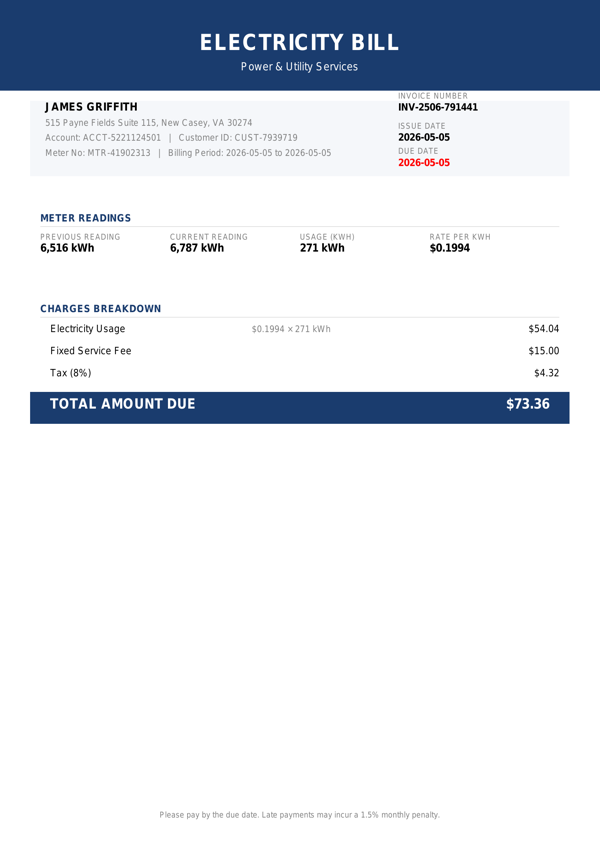

In [72]:
import os
from pdf2image import convert_from_path
from IPython.display import display

os.makedirs("dataset", exist_ok=True)
raw = step1_generate_invoice()

path = 'dataset/sample_invoice.pdf'
step2_create_invoice_pdf(raw, path)

images = convert_from_path(path)

for img in images:
    w, h = img.size
    new_w = 600
    new_h = int(h * new_w / w) 
    display(img.resize((new_w, new_h)))

In [ ]:
Generate 5000 sample.

In [60]:
import os
import json

def generate_all(output_dir="dataset", samples_per_type=1000):
    os.makedirs(output_dir, exist_ok=True)
    generated = []

    docs = [
        ("invoice",        step1_generate_invoice,        step2_create_invoice_pdf),
        ("passport",       step1_generate_passport,       step2_create_passport_pdf),
        ("certificate",    step1_generate_certificate,    step2_create_certificate_pdf),
        ("driver_license", step1_generate_driver_license, step2_create_driver_license_pdf),
        ("id_card",        step1_generate_id_card,        step2_create_id_card_pdf),
    ]

    for name, data_fn, pdf_fn in docs:
        type_dir = os.path.join(output_dir, name)
        os.makedirs(type_dir, exist_ok=True)
        
        for i in range(samples_per_type):
            data = data_fn()
            
            base_filename = f"{name}_{i+1:04d}"
            pdf_path = os.path.join(type_dir, f"{base_filename}.pdf")
            json_path = os.path.join(type_dir, f"{base_filename}.json")
            
            pdf_fn(data, pdf_path)
            
            with open(json_path, "w", encoding="utf-8") as f:
                json.dump(data, f, ensure_ascii=False, indent=4)
                
            generated.append(pdf_path)

    return generated

In [61]:
# import shutil
# shutil.rmtree("dataset")

In [62]:
files = generate_all(output_dir="dataset", samples_per_type=1000)
print(f"\nSum: {len(files)}")


Sum: 5000


## Milestone

Synthetic dataset (minimum 1,000+ samples per type) pushed to HF Hub.

In [70]:
from huggingface_hub import HfApi, login
from dotenv import load_dotenv
import os

load_dotenv()
token = os.getenv("HF_TOKEN")

def push_to_huggingface(dataset_dir, repo_id, token):
    login(token=token)
    api = HfApi()

    api.create_repo(repo_id=repo_id, repo_type="dataset", exist_ok=True)

    api.upload_folder(
        folder_path=dataset_dir,
        repo_id=repo_id,
        repo_type="dataset",
        commit_message="Push synthetic document dataset"
    )

if __name__ == "__main__":
    push_to_huggingface(
        dataset_dir="dataset",
        repo_id="Chino-01/dummy-dataset-documents-ocr",
        token=token
    )

It seems you are trying to upload a large folder at once. This might take some time and then fail if the folder is too large. For such cases, it is recommended to upload in smaller batches or to use `HfApi().upload_large_folder(...)`/`hf upload-large-folder` instead. For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/upload#upload-a-large-folder.
